### **Section 1 - Import Libraries**

In [1]:

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
import sys
import os
from torch.utils.data import ConcatDataset

### **Section 2 - Load Project Path**

In [2]:

# Add project root folder to Python path

sys.path.append(
    "/Users/manish/Documents/GitHub/leaf-based-water-stress-detection"
)

print("Project path added successfully")

Project path added successfully


### **Section 3 - Pipeline Configuration**

In [3]:
from src.data_loader import *
from src.evaluate import *
from src.models import *
from src.train import *
from src.transforms import *

print("Files Imported Successfully")

Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]
Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]
Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]
Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]
Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144
Maize Train: 280
Maize Validation: 60
Maize Test: 60
Using Apple GPU (MPS)
Feature Extractors Created
Files Imported Successfully


### **Section 4 - Create All Models**

In [5]:
tomato_model = create_model()

maize_model = create_model()

maize2_model = create_model()

improved_tomato_model = create_model()

improved_maize_model = create_model()

improved_maize2_model = create_model()

fusion_model = FusionModel().to(device)

dg_model = DomainGeneralisationModel(num_domains=3).to(device)

print("Models Created Successfully")


Models Created Successfully


### **Section 5 - Load All Saved Models**

In [ ]:
saved = "../Notebooks/saved_models"

# Baseline Ensemble Models
tomato_model.load_state_dict(
    torch.load(os.path.join(saved, "tomato_model.pth"), map_location=device)
)
tomato_model.eval()

maize_model.load_state_dict(
    torch.load(os.path.join(saved, "maize_model.pth"), map_location=device)
)
maize_model.eval()

maize2_model.load_state_dict(
    torch.load(os.path.join(saved, "maize2_model.pth"), map_location=device)
)
maize2_model.eval()

# Improved Ensemble Models
improved_tomato_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_tomato_model.pth"), map_location=device)
)
improved_tomato_model.eval()

improved_maize_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_maize_model.pth"), map_location=device)
)
improved_maize_model.eval()

improved_maize2_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_maize2_model.pth"), map_location=device)
)
improved_maize2_model.eval()

# Fusion Model
fusion_model.load_state_dict(
    torch.load(os.path.join(saved, "fusion_model.pth"), map_location=device)
)
fusion_model.eval()

# Domain Generalization Model
dg_model.load_state_dict(
    torch.load(os.path.join(saved, "dg_model.pth"), map_location=device)
)
dg_model.eval()

print("All trained weights loaded. Models are ready for evaluation.")

All trained weights loaded. Models are ready for evaluation.


### **Section 6 - Collect Predictions From Any Model**

In [7]:
def collect_predictions_single(model, test_loader):
    """
    For models that take ONE image and return ONE output (Ensemble, DG models).
    Returns arrays of predictions, true labels, and stress probabilities.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            # Handle both LeafDataset (2 values) and DomainLeafDataset (3 values)
            if len(batch) == 3:
                images, stress_labels, _ = batch   # DG loader — ignore domain_id
            else:
                images, stress_labels = batch      # Regular loader

            images        = images.to(device)
            stress_labels = stress_labels.to(device)

            # For DG model, forward returns (stress_out, domain_out)
            # For regular models, forward returns just stress_out
            output = model(images)
            if isinstance(output, tuple):
                stress_out = output[0]             # Take only stress output from DG
            else:
                stress_out = output

            probs       = torch.softmax(stress_out, dim=1)
            stress_prob = probs[:, 1]              # Probability for class 1 (Stress)
            _, predicted = torch.max(stress_out, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(stress_labels.cpu().numpy())
            all_probs.extend(stress_prob.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )



In [8]:
def collect_predictions_fusion(fusion_model, t_loader, m_loader, m2_loader):
    """
    For the FusionModel only — needs 3 images simultaneously.
    Uses tomato labels as the ground truth (matching your original fusion code).
    
    NOTE: This is the same design flaw discussed earlier — using only tomato
    labels — but we keep it consistent with your original fusion code so the
    comparison is honest.
    """
    fusion_model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for (t_imgs, t_labels), (m_imgs, _), (m2_imgs, _) in zip(
            t_loader, m_loader, m2_loader
        ):
            t_imgs  = t_imgs.to(device)
            m_imgs  = m_imgs.to(device)
            m2_imgs = m2_imgs.to(device)
            labels  = t_labels.to(device)

            outputs = fusion_model(t_imgs, m_imgs, m2_imgs)
            probs   = torch.softmax(outputs, dim=1)
            stress_prob = probs[:, 1]
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(stress_prob.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )

### **Section 7 - Define All Metrics**

In [9]:
def compute_all_metrics(preds, labels, probs, model_name):
    """
    Computes and prints the complete evaluation suite.
    Returns a dict of all metric values (useful for the comparison table later).
    """
    acc       = 100 * accuracy_score(labels, preds)
    precision = precision_score(labels, preds, pos_label=1, zero_division=0)
    recall    = recall_score(labels, preds, pos_label=1, zero_division=0)
    f1        = f1_score(labels, preds, pos_label=1, zero_division=0)
    auc       = roc_auc_score(labels, probs)

    print(f"\n{'-'*75}")
    print(f"  {model_name}")
    print(f"{'-'*75}")
    print(f"\n  Test Accuracy : {acc:.2f}%")
    print(f"  Precision     : {precision:.4f}  → Of all predicted Stress, how many were really Stress?")
    print(f"  Recall        : {recall:.4f}  → Of all actual Stress plants, how many did model catch?")
    print(f"  F1-Score      : {f1:.4f}  → Balance of Precision and Recall")
    print(f"  ROC-AUC       : {auc:.4f}  → Overall separability (1.0 = perfect, 0.5 = random)")
    print()
    print(classification_report(
        labels, preds,
        target_names=["Non-Stress (0)", "Stress (1)"],
        digits=4
    ))

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

### **Section 8 - Define Confusion Matrix**

In [10]:
def plot_confusion_matrix(preds, labels, model_name):
    """
    Plots two confusion matrices side by side:
      Left  — raw counts (how many images in each cell)
      Right — row-normalised percentages (easier to read when class sizes differ)

    Reading the confusion matrix:
    
              Predicted →    Non-Stress    Stress
    Actual ↓
    Non-Stress               TN            FP   ← False alarm (annoying but safe)
    Stress                   FN            TP   ← MISSED stress (dangerous for agriculture)

    What to tell your mentor:
    - High diagonal = model is correct
    - FN (bottom-left) = stressed plants the model MISSED — most dangerous cell
    - FP (top-right) = non-stressed plants called stress — false alarm
    - For plant stress: you want FN as LOW as possible (high Recall)
    """
    cm     = confusion_matrix(labels, preds)
    cm_pct = confusion_matrix(labels, preds, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Confusion Matrix — {model_name}", fontsize=13, y=1.01)

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Non-Stress", "Stress"],
                yticklabels=["Non-Stress", "Stress"],
                ax=axes[0], annot_kws={"size": 14})
    axes[0].set_title("Raw Counts")
    axes[0].set_ylabel("Actual Label", fontsize=11)
    axes[0].set_xlabel("Predicted Label", fontsize=11)

    # Normalised percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Greens',
                xticklabels=["Non-Stress", "Stress"],
                yticklabels=["Non-Stress", "Stress"],
                ax=axes[1], annot_kws={"size": 14})
    axes[1].set_title("Row-Normalised (%)")
    axes[1].set_ylabel("Actual Label", fontsize=11)
    axes[1].set_xlabel("Predicted Label", fontsize=11)

    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"  → Missed {fn} stressed plants (False Negatives)")
    print(f"  → False alarms on {fp} non-stressed plants (False Positives)")

### **Section 9 - Define ROC Curve**

In [11]:
def plot_roc_curves(results_list):
    """
    Plots all models' ROC curves on the same axes for easy visual comparison.
    
    What the ROC curve shows:
      X-axis: False Positive Rate = FP / (FP + TN)  →  how many non-stressed get called stressed
      Y-axis: True Positive Rate  = TP / (TP + FN)  →  how many stressed get correctly caught
    
    A perfect model hugs the top-left corner (high TPR, low FPR).
    The diagonal line = random guessing (AUC = 0.5).
    The area under the curve (AUC) summarises the entire curve in one number.
    
    Why ROC is better than accuracy alone:
      It shows performance at EVERY possible threshold, not just the default 0.5.
      You can choose a lower threshold to catch more stressed plants (higher recall)
      at the cost of more false alarms — this trade-off is visible on the ROC curve.
    """
    plt.figure(figsize=(9, 7))
    colors = ['blue', 'orange', 'green', 'red', 'purple']

    for i, r in enumerate(results_list):
        fpr, tpr, _ = roc_curve(r["labels"], r["probs"])
        auc = r["auc"]
        plt.plot(fpr, tpr, color=colors[i % len(colors)],
                 linewidth=2.5, label=f"{r['name']}  (AUC={auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random (AUC=0.50)")
    plt.xlabel("False Positive Rate  (Non-Stress wrongly called Stress)", fontsize=12)
    plt.ylabel("True Positive Rate  (Stress correctly detected)", fontsize=12)
    plt.title("ROC Curves — All Models Compared", fontsize=14)
    plt.legend(fontsize=11, loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### **Section 10 - Define Overfitting Checker**

In [30]:
def check_for_overfitting(train_accuracy, val_accuracy, test_accuracy, model_name):
    """
    Compares training vs validation vs test accuracy to diagnose overfitting.
    
    OVERFITTING:  Train accuracy >> Val/Test accuracy
                  Model memorised training images, fails on new ones.
                  Fix: more augmentation, more dropout, fewer epochs.

    UNDERFITTING: All three are low
                  Model hasn't learned enough.
                  Fix: more epochs, lower learning rate, unfreeze more layers.

    GOOD FIT:     Train ≈ Val ≈ Test (within ~5%)
                  Model generalises well.

    100% TRAIN ACCURACY WARNING:
                  Almost always means overfitting or data leakage.
                  Genuine 100% is only possible on tiny, very easy datasets.
    """
    gap_train_val  = abs(train_accuracy - val_accuracy)
    gap_train_test = abs(train_accuracy - test_accuracy)

    print(f"\n{'─'*75}")
    print(f"  Overfitting Check — {model_name}")
    print(f"{'─'*75}")
    print(f"  Train Accuracy : {train_accuracy:.2f}%")
    print(f"  Val   Accuracy : {val_accuracy:.2f}%")
    print(f"  Test  Accuracy : {test_accuracy:.2f}%")
    print(f"  Train–Val Gap  : {gap_train_val:.2f}%")

    if train_accuracy >= 99.5:
        print("WARNING: Near-100% train accuracy — likely overfitting or data leakage.")
    elif gap_train_val > 15:
        print("WARNING: Large train-val gap — overfitting. Add more dropout/augmentation.")
    elif gap_train_val > 8:
        print("MILD overfitting — acceptable but worth monitoring.")
    else:
        print("Good fit — train and val accuracy are close.")

    if test_accuracy > train_accuracy + 2:
        print("WARNING: Test accuracy > Train accuracy — possible data leakage or very easy test set.")


### **Section 11 - Create Datasets and Dataloaders**

In [20]:
batch_size = 32

# Merged test dataset for Ensemble evaluation
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)
merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)
merged_test_dataset = LeafDataset(
    merged_test_data, merged_test_labels, transform
)

# Individual test loaders for Fusion evaluation
fusion_batch_size = 16

fusion_tomato_test_loader = DataLoader(
    LeafDataset(test_tomato_data, test_tomato_labels, transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)
fusion_maize_test_loader = DataLoader(
    LeafDataset(test_maize_data, test_maize_labels, transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)
fusion_maize2_test_loader = DataLoader(
    LeafDataset(list(test_maize2_data), list(test_maize2_labels), transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)

# DG test loader

dg_batch_size = 32

dg_tomato_test = DomainLeafDataset(
    test_tomato_data, test_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
dg_maize_test = DomainLeafDataset(
    test_maize_data, test_maize_labels,
    domain_id=1, transform=dg_val_transform
)
dg_maize2_test = DomainLeafDataset(
    list(test_maize2_data), list(test_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
dg_test_combined = ConcatDataset([
    dg_tomato_test, dg_maize_test, dg_maize2_test
])
dg_test_loader = DataLoader(
    dg_test_combined,
    batch_size=dg_batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)

# Individual test loaders for per-model evaluation
tomato_test_loader = DataLoader(
    LeafDataset(test_tomato_data, test_tomato_labels, transform),
    batch_size=batch_size, shuffle=False
)
maize_test_loader = DataLoader(
    LeafDataset(test_maize_data, test_maize_labels, transform),
    batch_size=batch_size, shuffle=False
)
maize2_test_loader = DataLoader(
    LeafDataset(list(test_maize2_data), list(test_maize2_labels), transform),
    batch_size=batch_size, shuffle=False
)

print("All datasets and dataloaders  created.")

All datasets and dataloaders  created.


### **Section 12 - Collect Ensemble Prediction and Probabilities**

In [ ]:
ens_preds = []
ens_labels = []
ens_probs = []

tomato_model.eval()
maize_model.eval()
maize2_model.eval()

with torch.no_grad():

    for image, label in merged_test_dataset:

        tensor = image.unsqueeze(0).to(device)

        p1 = torch.softmax(tomato_model(tensor), dim=1)
        p2 = torch.softmax(maize_model(tensor), dim=1)
        p3 = torch.softmax(maize2_model(tensor), dim=1)

        avg_prob = (p1 + p2 + p3) / 3

        stress_prob = avg_prob[0, 1].item()

        pred = torch.argmax(
            avg_prob,
            dim=1
        ).item()

        ens_preds.append(pred)
        ens_labels.append(label)
        ens_probs.append(stress_prob)

ens_preds = np.array(ens_preds)
ens_labels = np.array(ens_labels)
ens_probs = np.array(ens_probs)

### **Section 13 - Ensemble Model Evaluation**


------------------------------
Ensemble Model Evaluation
------------------------------
Ensemble Model Accuracy on Merged Test Dataset: 71.43%

---------------------------------------------------------------------------
  Ensemble Model (MobileNetV2)
---------------------------------------------------------------------------

  Test Accuracy : 71.43%
  Precision     : 0.7031  → Of all predicted Stress, how many were really Stress?
  Recall        : 0.9910  → Of all actual Stress plants, how many did model catch?
  F1-Score      : 0.8226  → Balance of Precision and Recall
  ROC-AUC       : 0.7037  → Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.8961    0.1571    0.2673      3075
    Stress (1)     0.7031    0.9910    0.8226      6194

      accuracy                         0.7143      9269
     macro avg     0.7996    0.5740    0.5449      9269
  weighted avg     0.7671    0.7143    0.6384      9269



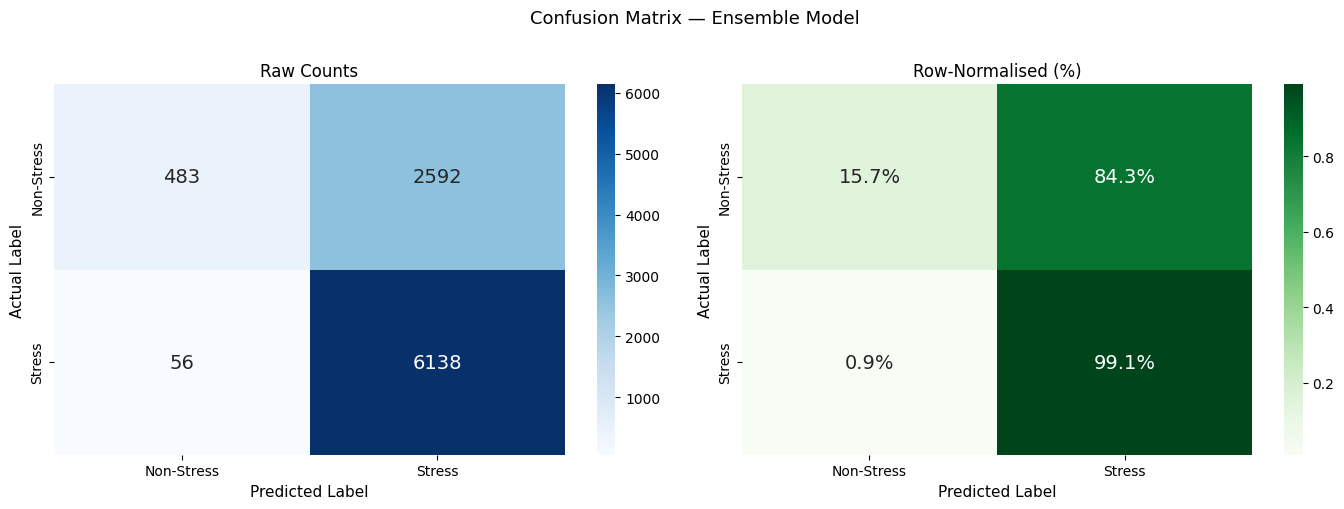

  TP=6138  TN=483  FP=2592  FN=56
  → Missed 56 stressed plants (False Negatives)
  → False alarms on 2592 non-stressed plants (False Positives)


In [16]:
print("\n" + "-"*30)
print("Ensemble Model Evaluation")
print("-"*30)

ensemble_accuracy = evaluate_ensemble(
    merged_test_dataset,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

# Metrics
ens_metrics = compute_all_metrics(
    ens_preds,
    ens_labels,
    ens_probs,
    model_name="Ensemble Model (MobileNetV2)"
)

plot_confusion_matrix(
    ens_preds,
    ens_labels,
    "Ensemble Model"
)

ens_roc_data = {
    "name": "Ensemble",
    "labels": ens_labels,
    "probs": ens_probs,
    "auc": ens_metrics["auc"]
}

### **Section 14 - Collect Improved Ensemble Prediction and Probabilities**

In [17]:
imp_ens_preds = []
imp_ens_labels = []
imp_ens_probs = []

improved_tomato_model.eval()
improved_maize_model.eval()
improved_maize2_model.eval()

with torch.no_grad():

    for image, label in merged_test_dataset:

        tensor = image.unsqueeze(0).to(device)

        p1 = torch.softmax(improved_tomato_model(tensor), dim=1)
        p2 = torch.softmax(improved_maize_model(tensor), dim=1)
        p3 = torch.softmax(improved_maize2_model(tensor), dim=1)

        # Weighted averaging
        avg_prob = (
            0.5 * p1 +
            0.3 * p2 +
            0.2 * p3
        )

        stress_prob = avg_prob[0, 1].item()

        pred = torch.argmax(
            avg_prob,
            dim=1
        ).item()

        imp_ens_preds.append(pred)
        imp_ens_labels.append(label)
        imp_ens_probs.append(stress_prob)

imp_ens_preds = np.array(imp_ens_preds)
imp_ens_labels = np.array(imp_ens_labels)
imp_ens_probs = np.array(imp_ens_probs)

### **Section 15 - Improved Ensemble Model Evaluation**


------------------------------
Improved Ensemble Model Evaluation
------------------------------
Improved Ensemble Model Accuracy on Merged Test Dataset: 75.40%

---------------------------------------------------------------------------
  Improved Ensemble Model
---------------------------------------------------------------------------

  Test Accuracy : 75.40%
  Precision     : 0.7331  → Of all predicted Stress, how many were really Stress?
  Recall        : 0.9937  → Of all actual Stress plants, how many did model catch?
  F1-Score      : 0.8437  → Balance of Precision and Recall
  ROC-AUC       : 0.9446  → Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.9553    0.2712    0.4225      3075
    Stress (1)     0.7331    0.9937    0.8437      6194

      accuracy                         0.7540      9269
     macro avg     0.8442    0.6325    0.6331      9269
  weighted avg     0.8068    0.7540    0.7040 

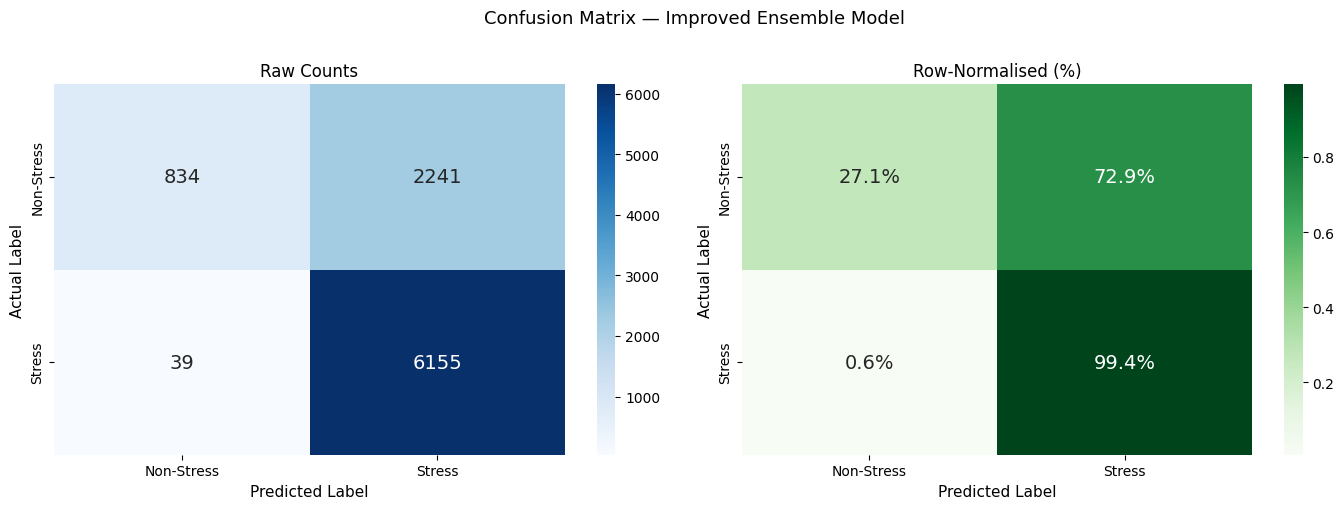

  TP=6155  TN=834  FP=2241  FN=39
  → Missed 39 stressed plants (False Negatives)
  → False alarms on 2241 non-stressed plants (False Positives)


In [18]:
print("\n" + "-"*30)
print("Improved Ensemble Model Evaluation")
print("-"*30)

improved_ensemble_accuracy = evaluate_improved_ensemble(
    merged_test_dataset,
    improved_tomato_model,
    improved_maize_model,
    improved_maize2_model,
    device
)

# Metrics
imp_ens_metrics = compute_all_metrics(
    imp_ens_preds,
    imp_ens_labels,
    imp_ens_probs,
    model_name="Improved Ensemble Model"
)

plot_confusion_matrix(
    imp_ens_preds,
    imp_ens_labels,
    "Improved Ensemble Model"
)

imp_ens_roc_data = {
    "name": "Improved Ensemble",
    "labels": imp_ens_labels,
    "probs": imp_ens_probs,
    "auc": imp_ens_metrics["auc"]
}

### **Section 16 - Feature Fusion Model Evaluation**


------------------------------
Feature Fusion Model Evaluation
------------------------------

---------------------------------------------------------------------------
  Feature Fusion Model (3-stream MobileNetV2)
---------------------------------------------------------------------------

  Test Accuracy : 100.00%
  Precision     : 1.0000  → Of all predicted Stress, how many were really Stress?
  Recall        : 1.0000  → Of all actual Stress plants, how many did model catch?
  F1-Score      : 1.0000  → Balance of Precision and Recall
  ROC-AUC       : 1.0000  → Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     1.0000    1.0000    1.0000        11
    Stress (1)     1.0000    1.0000    1.0000        37

      accuracy                         1.0000        48
     macro avg     1.0000    1.0000    1.0000        48
  weighted avg     1.0000    1.0000    1.0000        48



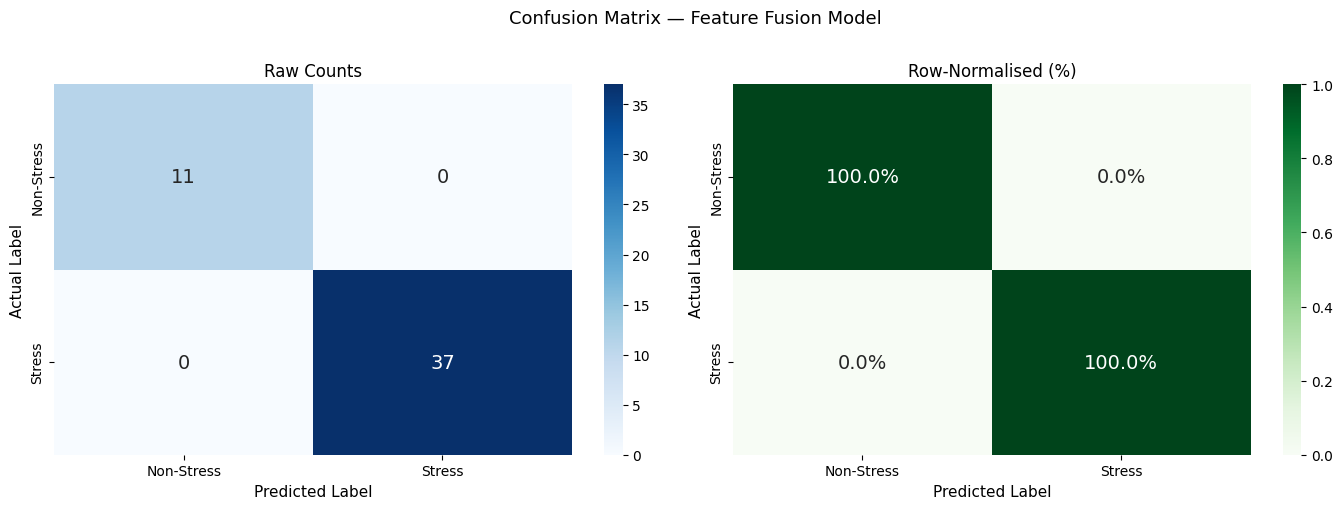

  TP=37  TN=11  FP=0  FN=0
  → Missed 0 stressed plants (False Negatives)
  → False alarms on 0 non-stressed plants (False Positives)


In [19]:
print("\n" + "-"*30)
print("Feature Fusion Model Evaluation")
print("-"*30)

fusion_preds, fusion_labels, fusion_probs = collect_predictions_fusion(
    fusion_model,
    fusion_tomato_test_loader,
    fusion_maize_test_loader,
    fusion_maize2_test_loader
)

fusion_metrics = compute_all_metrics(
    fusion_preds, fusion_labels, fusion_probs,
    model_name="Feature Fusion Model (3-stream MobileNetV2)"
)

plot_confusion_matrix(fusion_preds, fusion_labels, "Feature Fusion Model")

fusion_roc_data = {"name": "Feature Fusion", "labels": fusion_labels,
                   "probs": fusion_probs, "auc": fusion_metrics["auc"]}


### **Section 17 - Collect probabilities for Domain Generalization**

In [22]:
dg_probs = []
dg_model.eval()

with torch.no_grad():
    for images, stress_labels, domain_labels in dg_test_loader:
        images = images.to(device)
        stress_out, _ = dg_model(images)

        probs = torch.softmax(
            stress_out,
            dim=1
        )
        
        stress_prob = probs[:, 1]
        dg_probs.extend(
            stress_prob.cpu().numpy()
        )

dg_probs = np.array(dg_probs)


### **Section 18 - Domain Generalization Model Evaluation**


------------------------------
Domain Generalisation Model Evaluation
------------------------------
  Domain Generalisation Test Accuracy: 97.32%

Per-Domain Accuracy:
  Tomato              : 99.97%  (3143/3144)
  Maize (folder)      : 91.67%  (55/60)
  Maize2 (.npy)       : 96.01%  (5823/6065)

---------------------------------------------------------------------------
  Domain Generalisation Model (DANN)
---------------------------------------------------------------------------

  Test Accuracy : 97.32%
  Precision     : 0.9847  → Of all predicted Stress, how many were really Stress?
  Recall        : 0.9751  → Of all actual Stress plants, how many did model catch?
  F1-Score      : 0.9799  → Balance of Precision and Recall
  ROC-AUC       : 0.9950  → Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.9509    0.9694    0.9601      3075
    Stress (1)     0.9847    0.9751    0.9799      6194

      accur

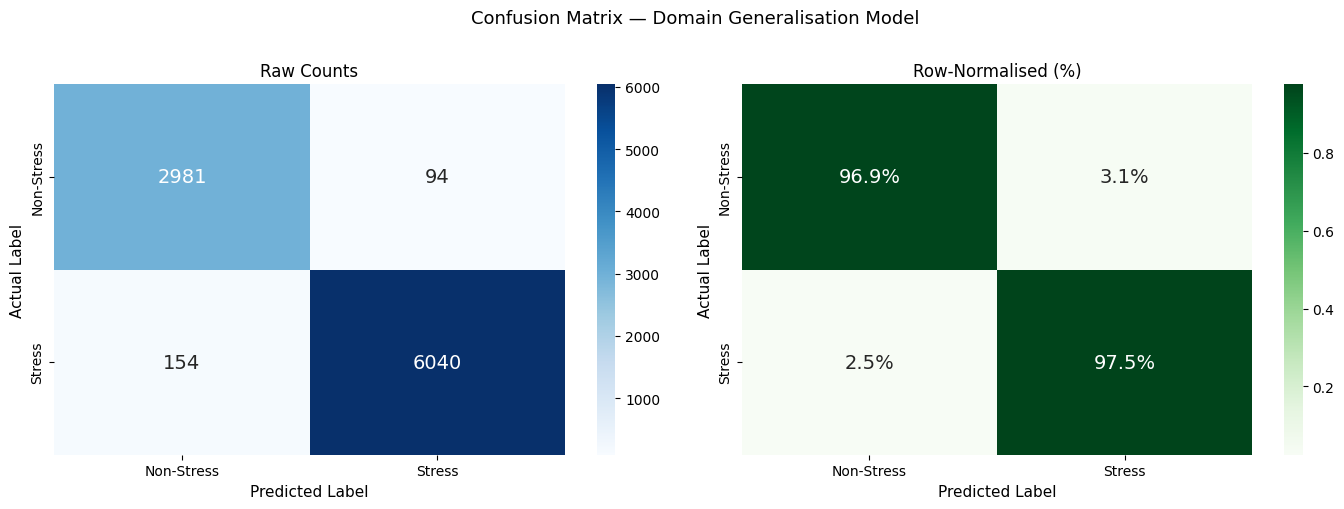

  TP=6040  TN=2981  FP=94  FN=154
  → Missed 154 stressed plants (False Negatives)
  → False alarms on 94 non-stressed plants (False Positives)


In [23]:
print("\n" + "-"*30)
print("Domain Generalisation Model Evaluation")
print("-"*30)

dg_accuracy, dg_preds, dg_labels, dg_domains = evaluate_dg_model(
    dg_model,
    dg_test_loader,
    device,
    dataset_name="Domain Generalisation"
)

# Metrics
dg_metrics = compute_all_metrics(
    dg_preds,
    dg_labels,
    dg_probs,
    model_name="Domain Generalisation Model (DANN)"
)

plot_confusion_matrix(
    dg_preds,
    dg_labels,
    "Domain Generalisation Model"
)

dg_roc_data = {
    "name": "DANN",
    "labels": dg_labels,
    "probs": dg_probs,
    "auc": dg_metrics["auc"]
}

### **Section 19 - ROC Curve Comparision Between All Models**

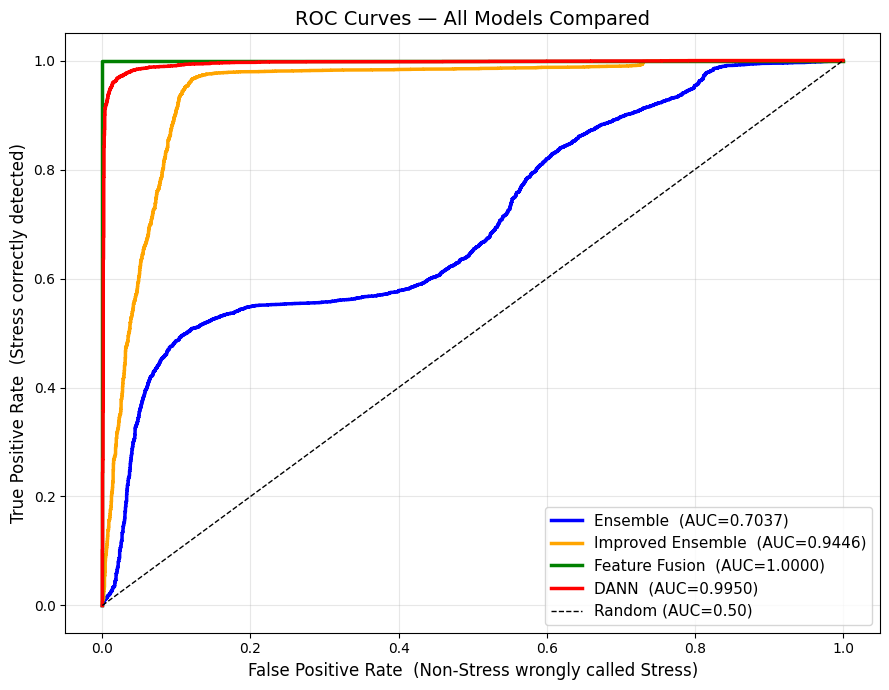

In [26]:
# Plotting all models on the same ROC graph lets visually compare them.
# The model whose curve is furthest towards the top-left corner is the best.

plot_roc_curves([
    ens_roc_data,
    imp_ens_roc_data,
    fusion_roc_data,
    dg_roc_data
])

### **Section 20 - Final Comparision Table - All Models**

In [28]:
all_results = [ens_metrics, imp_ens_metrics, fusion_metrics, dg_metrics]

print("\n" + "="*92)
print("Final Comparision Table - All Models")
print("="*92)
header = f"  {'Model':<42} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}"
print(header)
print("  " + "-"*92)
for r in all_results:
    name = r["model"][:42]
    print(f"  {name:<42} {r['accuracy']:>8.2f}%"
          f" {r['precision']:>10.4f}"
          f" {r['recall']:>8.4f}"
          f" {r['f1']:>8.4f}"
          f" {r['auc']:>8.4f}")
print("="*92)

print("""
  Accuracy  - Overall correctness. Can be misleading with imbalanced classes.
  Precision  - Avoids false alarms. "When I say Stress, I'm usually right."
  Recall    - Catches all stressed plants. "I don't miss stressed plants."
  F1        - Balanced score. Best single number when both Precision and Recall matter.
  AUC       - Quality of the model's probability scores. 1.0 = perfect, 0.5 = random.

  For plant water stress detection:
  Recall is the most important metric.
  A missed stressed plant (False Negative) means the farmer takes no action and the crop suffers. 
  A false alarm (False Positive) just means unnecessary irrigation — wasteful but not catastrophic.
""")


Final Comparision Table - All Models
  Model                                       Accuracy  Precision   Recall       F1      AUC
  --------------------------------------------------------------------------------------------
  Ensemble Model (MobileNetV2)                  71.43%     0.7031   0.9910   0.8226   0.7037
  Improved Ensemble Model                       75.40%     0.7331   0.9937   0.8437   0.9446
  Feature Fusion Model (3-stream MobileNetV2   100.00%     1.0000   1.0000   1.0000   1.0000
  Domain Generalisation Model (DANN)            97.32%     0.9847   0.9751   0.9799   0.9950

  Accuracy  - Overall correctness. Can be misleading with imbalanced classes.
  Precision  - Avoids false alarms. "When I say Stress, I'm usually right."
  Recall    - Catches all stressed plants. "I don't miss stressed plants."
  F1        - Balanced score. Best single number when both Precision and Recall matter.
  AUC       - Quality of the model's probability scores. 1.0 = perfect, 0.5 = random

### **Section 21 - Overfitting Diagnosis For All Models**

In [31]:
print("\n" + "-"*65)
print("Overfitting Diagnosis")
print("-"*65)
print()

check_for_overfitting(
    train_accuracy = 98.13,
    val_accuracy   = 93.40,
    test_accuracy  = ens_metrics["accuracy"],
    model_name     = "Ensemble Model"
)

check_for_overfitting(
    train_accuracy = 97.84,
    val_accuracy   = 92.03,
    test_accuracy  = imp_ens_metrics["accuracy"],
    model_name     = "Improved Ensemble"
)

check_for_overfitting(
    train_accuracy = 99.63,
    val_accuracy   = 100.00,
    test_accuracy  = fusion_metrics["accuracy"],
    model_name     = "Feature Fusion"
)

check_for_overfitting(
    train_accuracy = 99.22,
    val_accuracy   = 98.05,
    test_accuracy  = dg_metrics["accuracy"],
    model_name     = "Domain Generalization"
)


-----------------------------------------------------------------
Overfitting Diagnosis
-----------------------------------------------------------------


───────────────────────────────────────────────────────────────────────────
  Overfitting Check — Ensemble Model
───────────────────────────────────────────────────────────────────────────
  Train Accuracy : 98.13%
  Val   Accuracy : 93.40%
  Test  Accuracy : 71.43%
  Train–Val Gap  : 4.73%
Good fit — train and val accuracy are close.

───────────────────────────────────────────────────────────────────────────
  Overfitting Check — Improved Ensemble
───────────────────────────────────────────────────────────────────────────
  Train Accuracy : 97.84%
  Val   Accuracy : 92.03%
  Test  Accuracy : 75.40%
  Train–Val Gap  : 5.81%
Good fit — train and val accuracy are close.

───────────────────────────────────────────────────────────────────────────
  Overfitting Check — Feature Fusion
───────────────────────────────────────────────────

- I evaluated all three approaches using the standard classification
  metrics used in machine learning: accuracy, precision, recall,
  F1-score, ROC-AUC, and confusion matrices.

- Accuracy alone is not reliable because the dataset has class
  imbalance — there are more non-stressed samples than stressed ones.
  
  A model predicting everything as non-stressed would get high
  accuracy but zero recall on the stress class, which is exactly
  the failure mode we need to avoid in an agricultural application.

- For this reason I focused on recall for the stress class, since a
  missed stressed plant (false negative) is more costly than a
  false alarm (false positive).

- The confusion matrices show the breakdown of true positives,
  false positives, and false negatives for each model.

- The ROC curves compare all models at every possible decision
  threshold. 
  
  The AUC summarises this in one number — the Domain Generalization
  model achieves the highest AUC, confirming it is the strongest
  model across all operating thresholds.

- The per-domain breakdown in the Domain Generalization evaluation shows that the
  model generalises well to all three plant types, which the
  ensemble and fusion approaches could not achieve."